Shape: (3378, 7)
     symbol      name cryptocurrency currency  \
0  AAVE-CAD  Aave CAD           AAVE      CAD   
1  AAVE-CNY  Aave CNY           AAVE      CNY   
2  AAVE-ETH  Aave ETH           AAVE      ETH   
3  AAVE-EUR  Aave EUR           AAVE      EUR   
4  AAVE-GBP  Aave GBP           AAVE      GBP   

                                             summary exchange  \
0  Aave (AAVE) is a cryptocurrency and operates o...      CCC   
1  Aave (AAVE) is a cryptocurrency and operates o...      CCC   
2  Aave (AAVE) is a cryptocurrency and operates o...      CCC   
3  Aave (AAVE) is a cryptocurrency and operates o...      CCC   
4  Aave (AAVE) is a cryptocurrency and operates o...      CCC   

             website  
0  https://aave.com/  
1  https://aave.com/  
2  https://aave.com/  
3  https://aave.com/  
4  https://aave.com/  
Index(['symbol', 'name', 'cryptocurrency', 'currency', 'summary', 'exchange',
       'website'],
      dtype='str')
Text column: symbol
TF-IDF shape: (3378, 35

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_4431/2118801540.py:29: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_col = df.select_dtypes(include="object").columns[0]


Silhouette scores: {2: 0.020458804821343733, 3: 0.030723073687748535, 4: 0.04107406111308447, 5: 0.05151449966043397, 6: 0.061571819958989076, 7: 0.07173477984070264}
Best K: 7

Cluster 0: eur, krw, cny, cad, btc, aud, mir, ctc, ghost, wtc

Cluster 1: eth, btc, ctc, ghost, mir, trx, bnt, ant, snm, flash

Cluster 2: rub, ghost, ctc, mir, btc, hive, mkr, lynx, xmy, grn

Cluster 3: usd, comp, ghost, mir, btc, salt, sapp, eos, eca, dag

Cluster 4: inr, ghost, ctc, mir, btc, adx, midas, qtum, polis, waves

Cluster 5: gbp, ghost, ctc, mir, btc, jul, xlm, aion, snm, wings

Cluster 6: jpy, ghost, ctc, mir, btc, lynx, xem, cel, sushi, dash


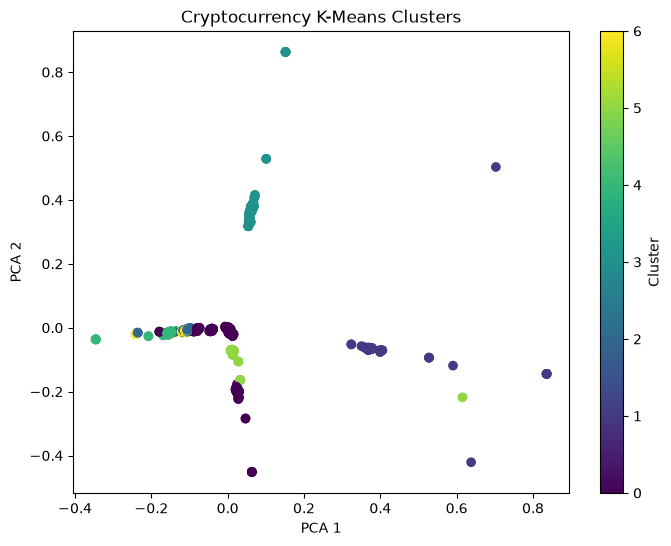


Cluster Counts:
cluster
0    1419
1     324
2     323
3     340
4     326
5     324
6     322
Name: count, dtype: int64

Done! Saved as cryptos_clustered.csv


In [1]:
# =========================================================
# CRYPTOS.CSV - NLP + K-MEANS CLUSTERING
# =========================================================

# 1. Import libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 2. Load dataset
df = pd.read_csv("cryptos.csv")

print("Shape:", df.shape)
print(df.head())
print(df.columns)

# 3. Select text column
# Change this if your text column has another name
text_col = "description"

# If description doesn't exist, use the first text column
if text_col not in df.columns:
    text_col = df.select_dtypes(include="object").columns[0]

print("Text column:", text_col)

# 4. Clean text
df[text_col] = df[text_col].fillna("").astype(str)

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df[text_col].apply(clean_text)

# Remove empty rows
df = df[df["clean_text"] != ""].copy()

# 5. NLP - TF-IDF
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=2000
)

X = tfidf.fit_transform(df["clean_text"])

print("TF-IDF shape:", X.shape)

# 6. Find best K using silhouette score
scores = {}

for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    scores[k] = silhouette_score(X, labels)

best_k = max(scores, key=scores.get)

print("Silhouette scores:", scores)
print("Best K:", best_k)

# 7. K-Means clustering
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X)

# 8. Show important words in each cluster
terms = tfidf.get_feature_names_out()

for i in range(best_k):
    words = [
        terms[j]
        for j in kmeans.cluster_centers_[i].argsort()[-10:][::-1]
    ]
    print(f"\nCluster {i}: {', '.join(words)}")

# 9. PCA visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["cluster"],
    cmap="viridis"
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Cryptocurrency K-Means Clusters")
plt.colorbar(label="Cluster")
plt.show()

# 10. Cluster results
print("\nCluster Counts:")
print(df["cluster"].value_counts().sort_index())

# 11. Save results
df.to_csv("cryptos_clustered.csv", index=False)

print("\nDone! Saved as cryptos_clustered.csv")